In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import numpy as np
import torch
torch.set_default_dtype(torch.float64)

from matplotlib import pyplot as plt

from scipy.special import logit
from scipy.stats import norm

In [26]:
import sys
import os
sys.path.append(os.path.abspath('/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation'))

from src.config import DataConfig, AlgorithmConfig
from src.objectives import LipschitzSelection, HardSelection
from src.dgp import IsotropicGaussian
from src.asymptotics import MacroscopicStateEvolution
from src.algorithms import SelfTrainedGradientDescent
from src.callbacks import TestEvaluatorCallback
from src.utils import plot_autograd_dag

from scripts.runner import MonteCarloExperiment

In [27]:
delta = 20.0
rho = 0.01
p = 0.2
sigma = 1.0

def nu_mu_1(seed: int = None, mean: float = 1.0, std: float = 1.0) -> float:
    rng = None if seed is None else torch.Generator().manual_seed(seed)
    return torch.normal(mean=mean, std=std, size=(1,), generator=rng).item()

def nu_mu_2(seed: int = None, mean: float = 1.0, std: float = 1.0) -> float:
    rng = None if seed is None else torch.Generator().manual_seed(seed)
    euler_gamma = 0.5772156649
    scale = (std * np.sqrt(6)) / np.pi
    loc = mean - (scale * euler_gamma)
    
    u = torch.rand(size=(1,), generator=rng)
    
    gumbel_sample = loc - scale * torch.log(-torch.log(u + 1e-20))
    
    return gumbel_sample.item()



def nu_mu(seed: int = None, mean: float = 1.0, std: float = 1.0) -> float:

    rng = None if seed is None else torch.Generator().manual_seed(seed)
    
    # 1. Define mixing probabilities (Right peak is larger/more probable)
    p_left = 0.3
    p_right = 0.7
    
    # 2. Define component locations and tighter spreads
    mu_left, mu_right = -1.0, 2.0
    component_std = 0.5
    component_var = component_std ** 2  # 0.25
    
    # 3. Calculate the true mathematical mean of this specific asymmetric mixture
    # E[X] = p1*mu1 + p2*mu2
    base_mean = (p_left * mu_left) + (p_right * mu_right)  # 0.3*(-1) + 0.7*(2) = 1.1
    
    # 4. Calculate the true mathematical variance of this asymmetric mixture
    # Var(X) = p1*(sigma1^2 + mu1^2) + p2*(sigma2^2 + mu2^2) - E[X]^2
    raw_second_moment = (p_left * (component_var + mu_left**2)) + (p_right * (component_var + mu_right**2))
    base_var = raw_second_moment - (base_mean ** 2)       # 3.275 - 1.21 = 2.065
    base_std = np.sqrt(base_var)                        # Approximately 1.43701
    
    # 5. Categorical choice: flip a biased coin to select the component
    u = torch.rand(size=(1,), generator=rng).item()
    center = mu_left if u < p_left else mu_right
    
    # 6. Sample Gaussian noise for the chosen component
    noise = torch.randn(size=(1,), generator=rng).item()
    base_sample = center + (noise * component_std)
    
    # 7. Standardize the sample, then scale it to the exact target mean and std
    normalized_sample = mean + std * ((base_sample - base_mean) / base_std)
    
    return normalized_sample




1.0076690768265923 0.9966523633296522


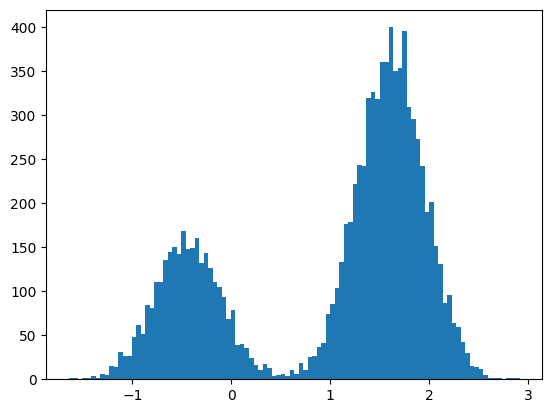

In [28]:
l = [nu_mu() for i in range(10000)]
plt.hist(l, bins = 100)
print(np.mean(l), np.std(l))

In [29]:
data_cfg = DataConfig(
    scale=sigma,
    label_prior=p,
    supervision_ratio=rho,
    data_to_dimension_ratio=delta,
    signal_law=nu_mu,  
)

data = IsotropicGaussian(
    cfg=data_cfg, 
    n_train=10000,
    n_test=5000,
    dimensions=500,
    seed=42
)

X_lab, Y_lab, X_unl, Y_unl, X_test, Y_test = data.sample()

In [30]:
metrics = {
    "test_error", "population_error", "unl_usage", 
    "train_mean_residual", "train_label_residual_alignment", 
    "weight_signal_alignment", "weight_vector_norm", "bias_term"
}

In [31]:
def plot_callback(callback):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # --- Plot 1: Errors ---
    axes[0, 0].plot(
        callback.history_["population_error"], label='Population Error', 
        linestyle='--', color='red'
    )
    axes[0, 0].plot(callback.history_["test_error"], label='Test Error')
    axes[0, 0].set_ylim(0.0, 0.5)
    axes[0, 0].set_title(f'Error Evolution')

    # --- Plot 2: Unlabeled Usage ---
    axes[0, 1].plot(callback.history_["unl_usage"], label='Unlabeled Usage')
    axes[0, 1].set_title('Unlabeled Usage Evolution')

    # --- Plot 3: Bias Term ---
    axes[0, 2].plot(callback.history_["bias_term"], label='Bias Term')
    axes[0, 2].set_title(
        f'Bias Evolution (Include Bias = {algorithm_cfg.include_bias})'
    )

    # --- Plot 4: Weight-Signal Alignment ---
    axes[1, 0].plot(
        callback.history_["weight_signal_alignment"], 
        label="Weight-Signal Alignm."
    )
    axes[1, 0].set_title(f'Weight-Signal Alignm. Evolution ')

    # --- Plot 5: Label-PseudoResidual Alignment ---
    axes[1, 1].plot(
        callback.history_["train_label_residual_alignment"], 
        label="Label-Residual Alignm."
    )
    axes[1, 1].set_title(' Label-PseudoResidual Alignm. Evolution')

    # --- Plot 6: Mean PseudoResidual ---
    axes[1, 2].plot(
        callback.history_["train_mean_residual"], 
        label="Mean Residual"
    )
    axes[1, 2].set_title('Mean PseudoResidual Evolution')

    for ax in axes.flatten():
        ax.set_xlabel('Iteration')
        ax.legend()
        ax.grid(which='major', color='#999999', linestyle='-', linewidth=0.8)
        ax.grid(which='minor', color='#999999', linestyle=':', linewidth=0.5)
        ax.minorticks_on()

    fig.suptitle("Evolution of Macroscopic quantities", fontsize=20)


    plt.tight_layout()
    plt.show()

## Configuration 0a - Supervised Learning Baseline

In [32]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=1500,
    ramp_end=1500,
    positive_margin=logit(0.80),
    negative_margin=-logit(0.80),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=True
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

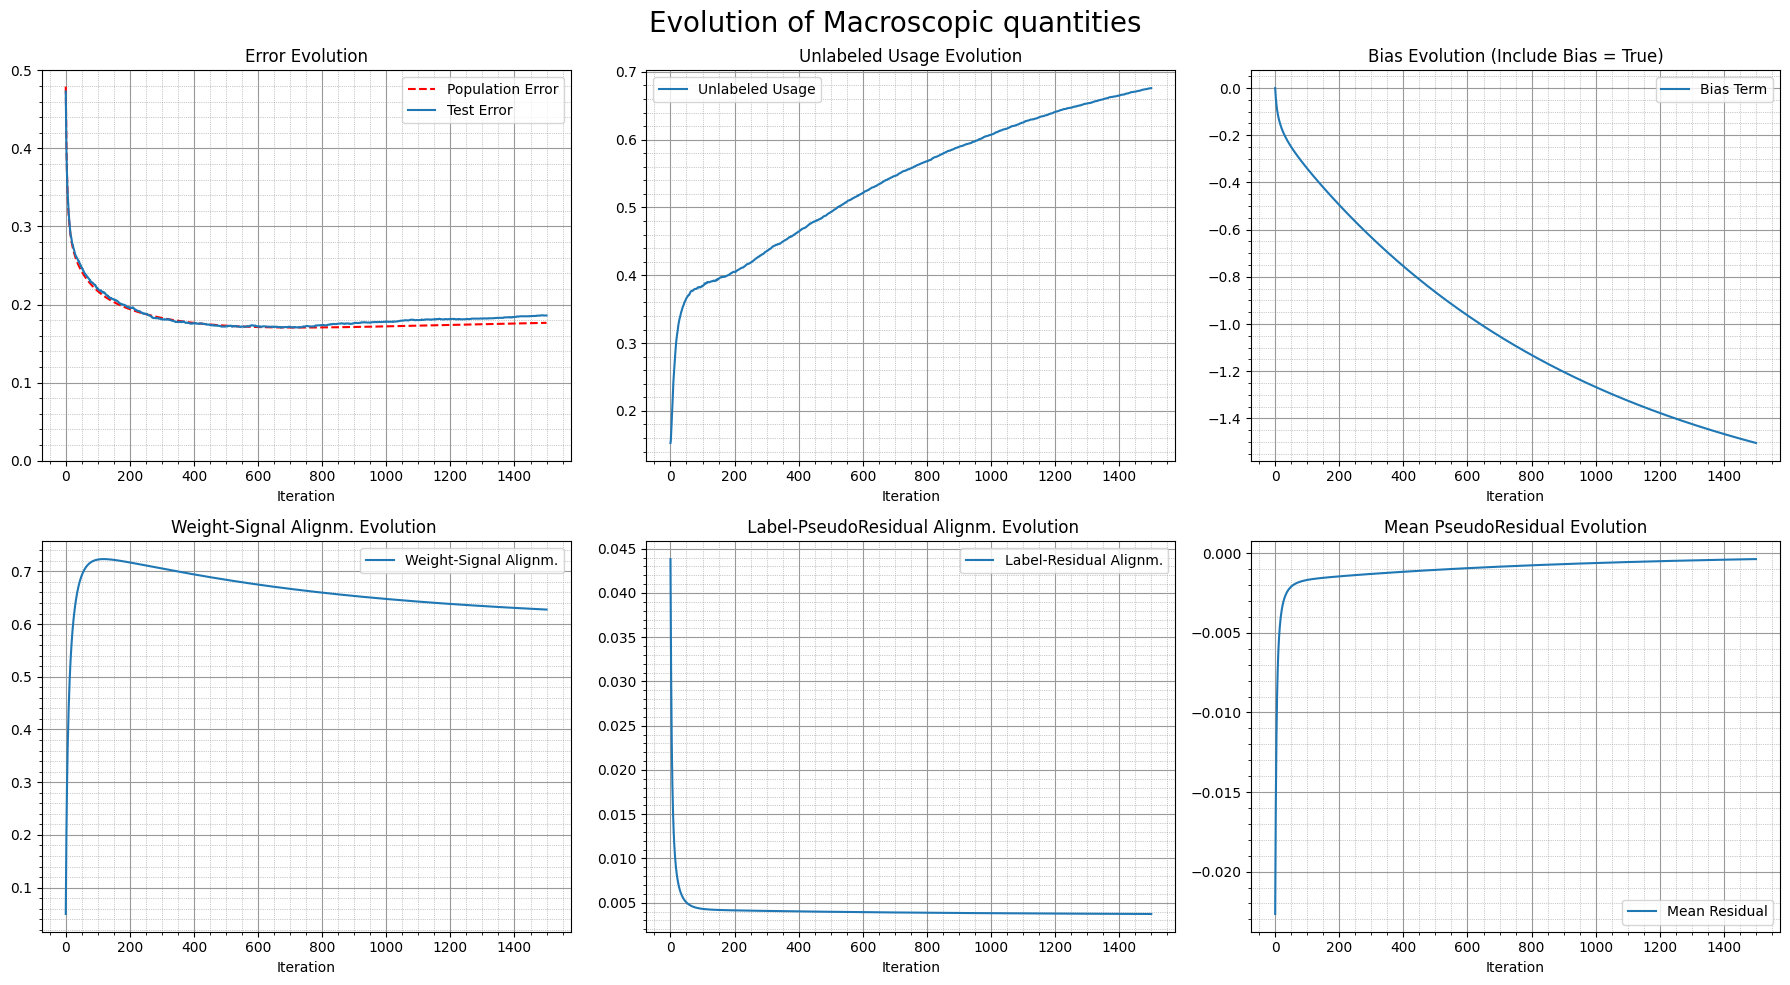

In [33]:
plot_callback(callback)

In [38]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=1500,
    ramp_end=1500,
    positive_margin=logit(0.80),
    negative_margin=-logit(0.80),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

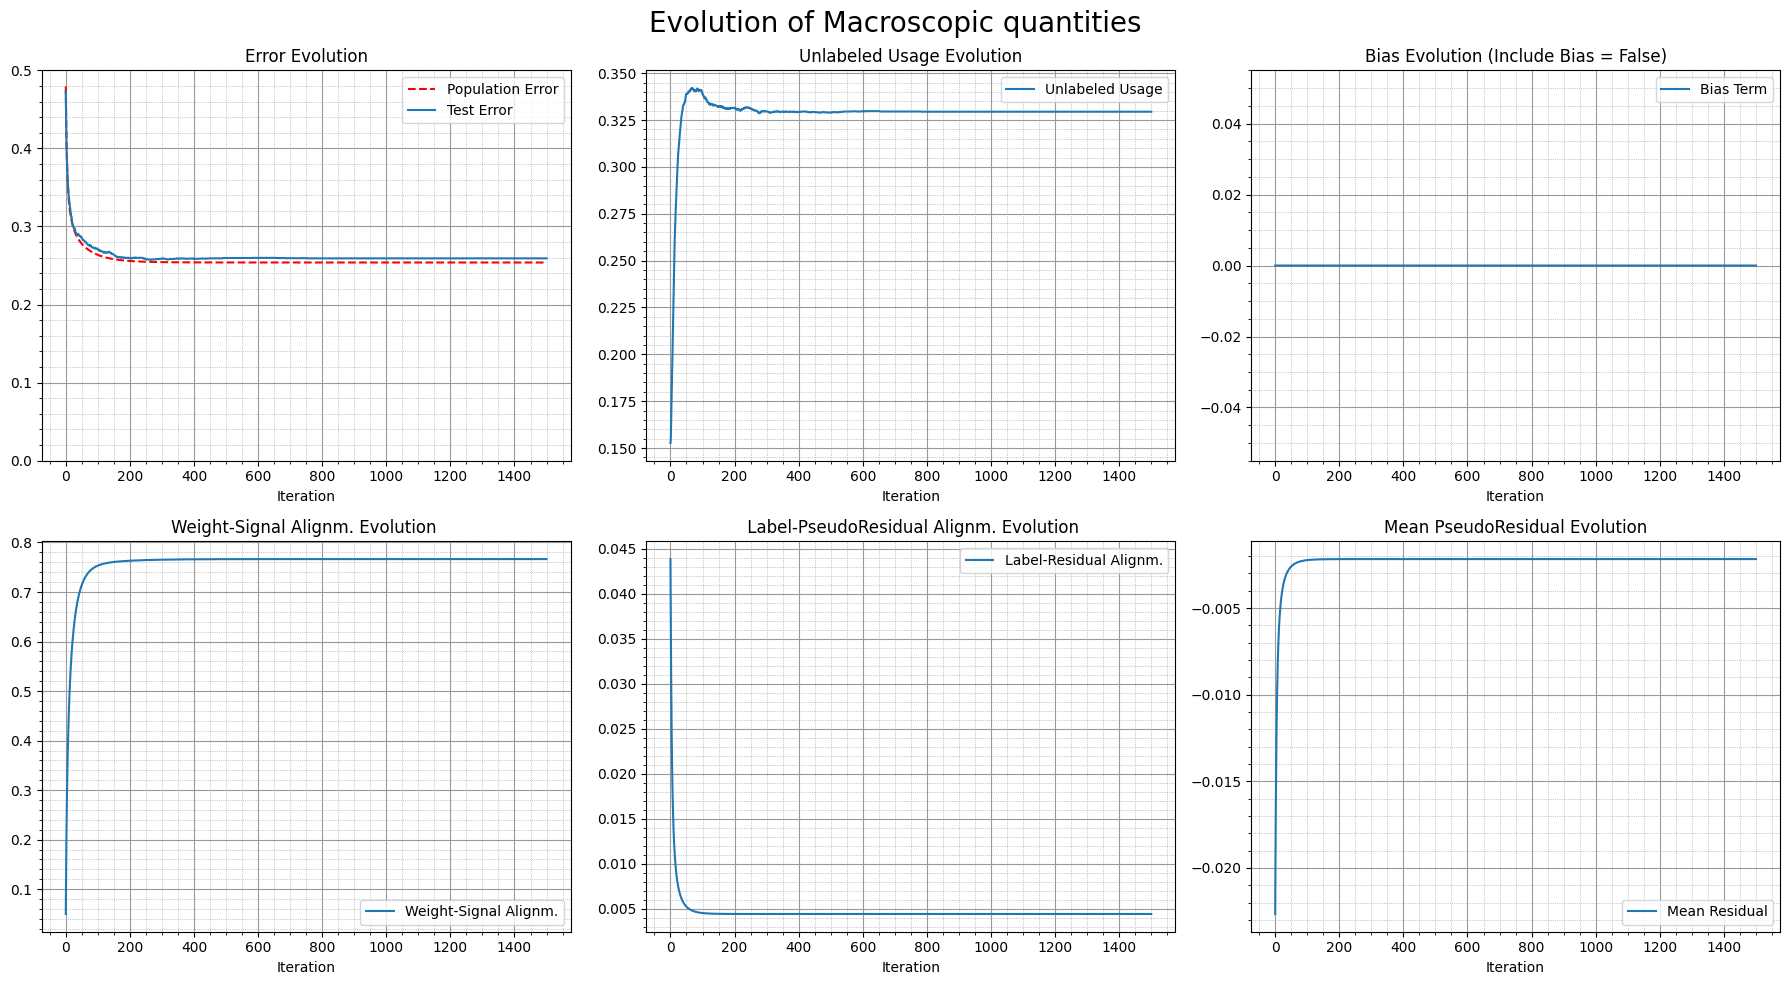

In [39]:
plot_callback(callback)

## Configuration 0b - No burn in period

In [34]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=0,
    ramp_end=0,
    positive_margin=logit(0.80),
    negative_margin=-logit(0.80),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=True
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

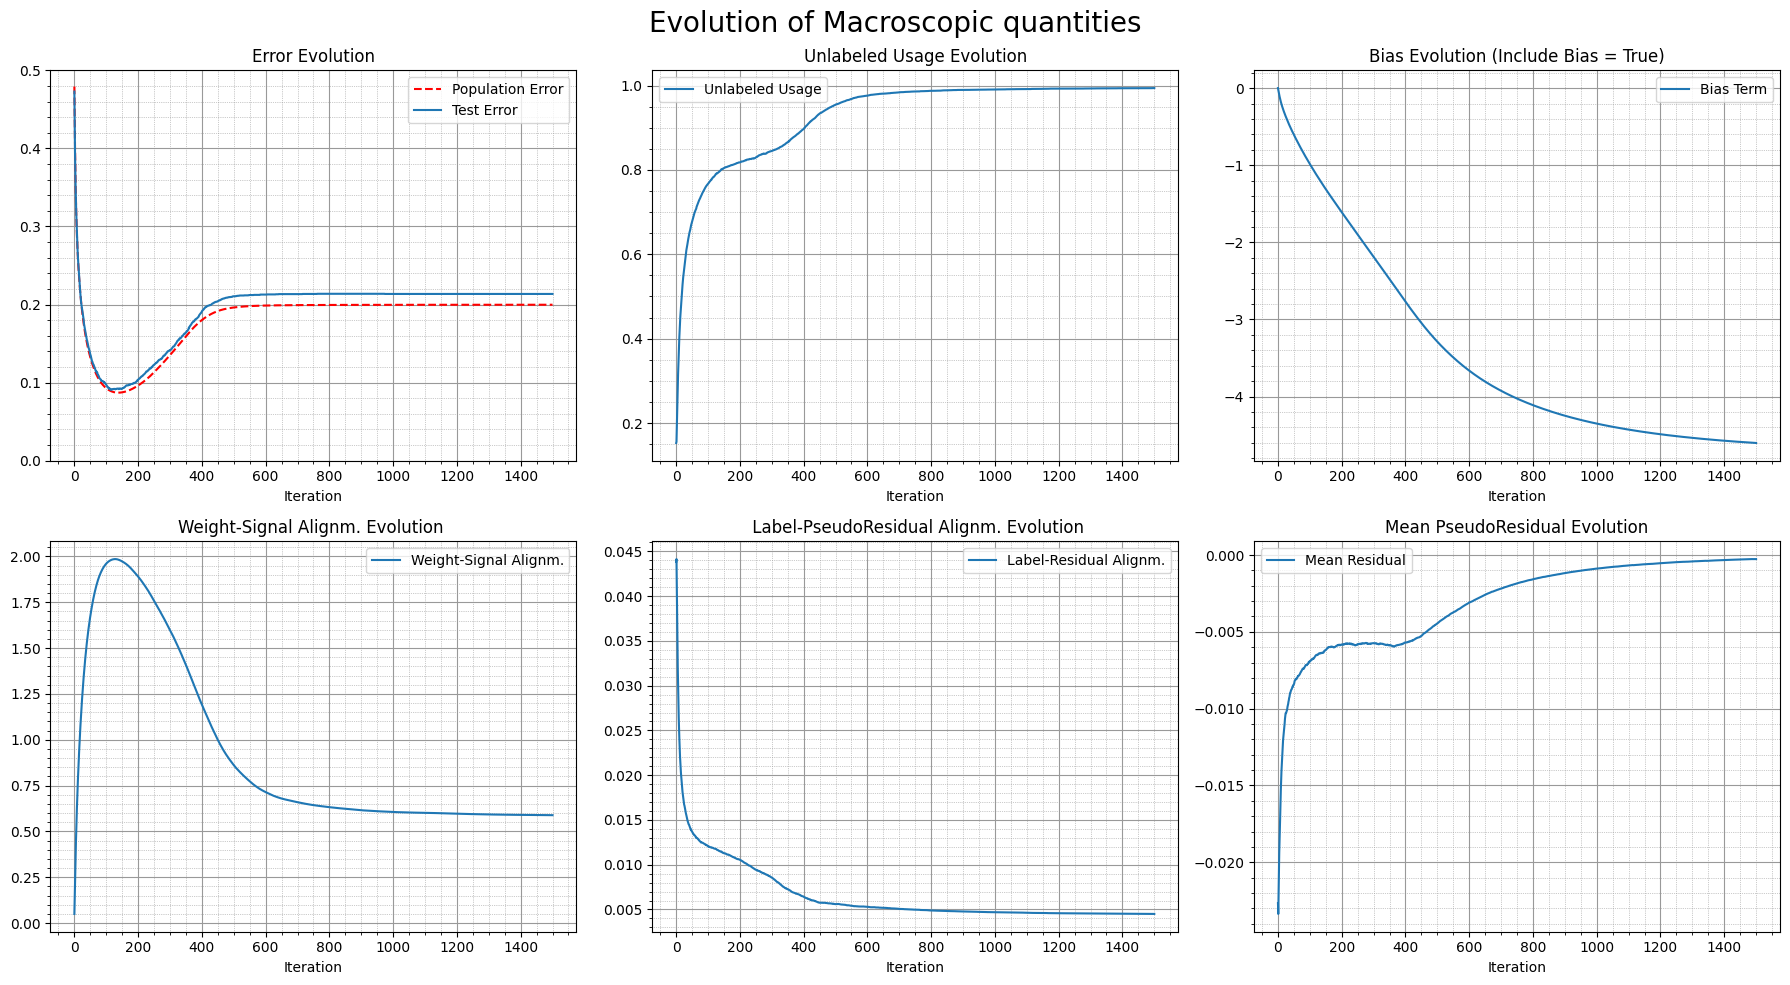

In [35]:
plot_callback(callback)

In [40]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=0,
    ramp_end=0,
    positive_margin=logit(0.80),
    negative_margin=-logit(0.80),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

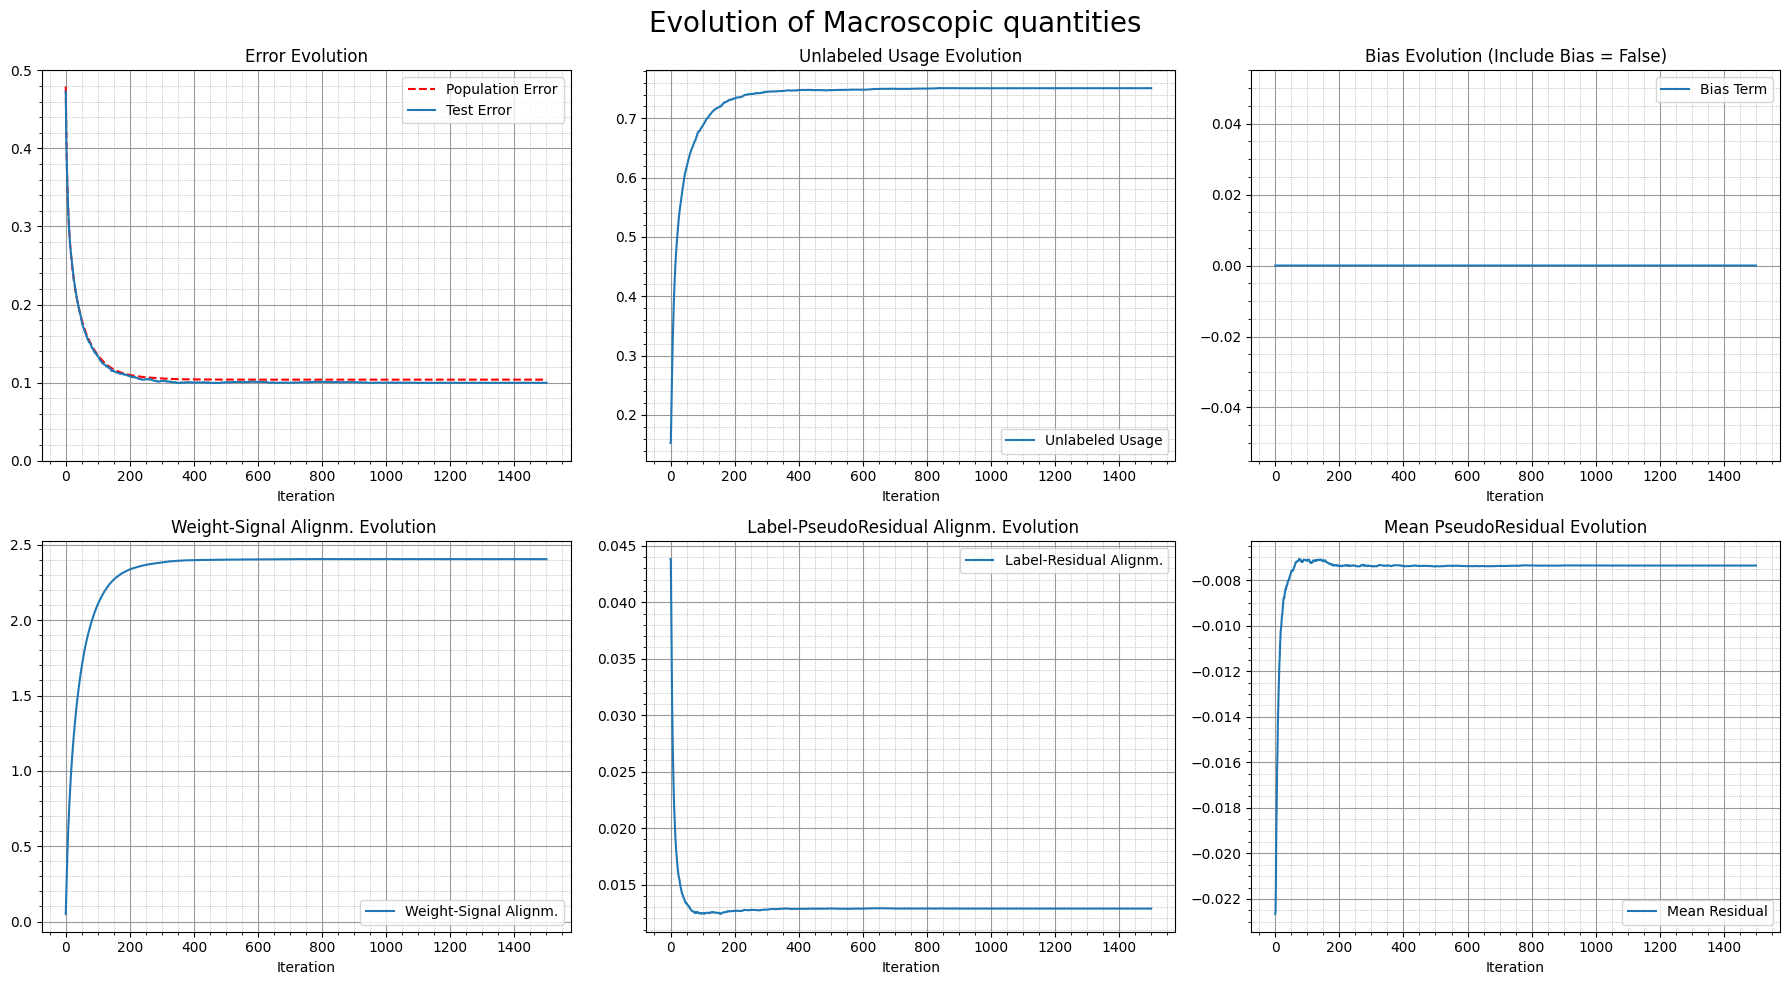

In [41]:
plot_callback(callback)

## Configuration 1 - Symmetric Margins, With Bias, Small Pseudo-Label Param

In [42]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.80),
    negative_margin=-logit(0.80),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=True
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

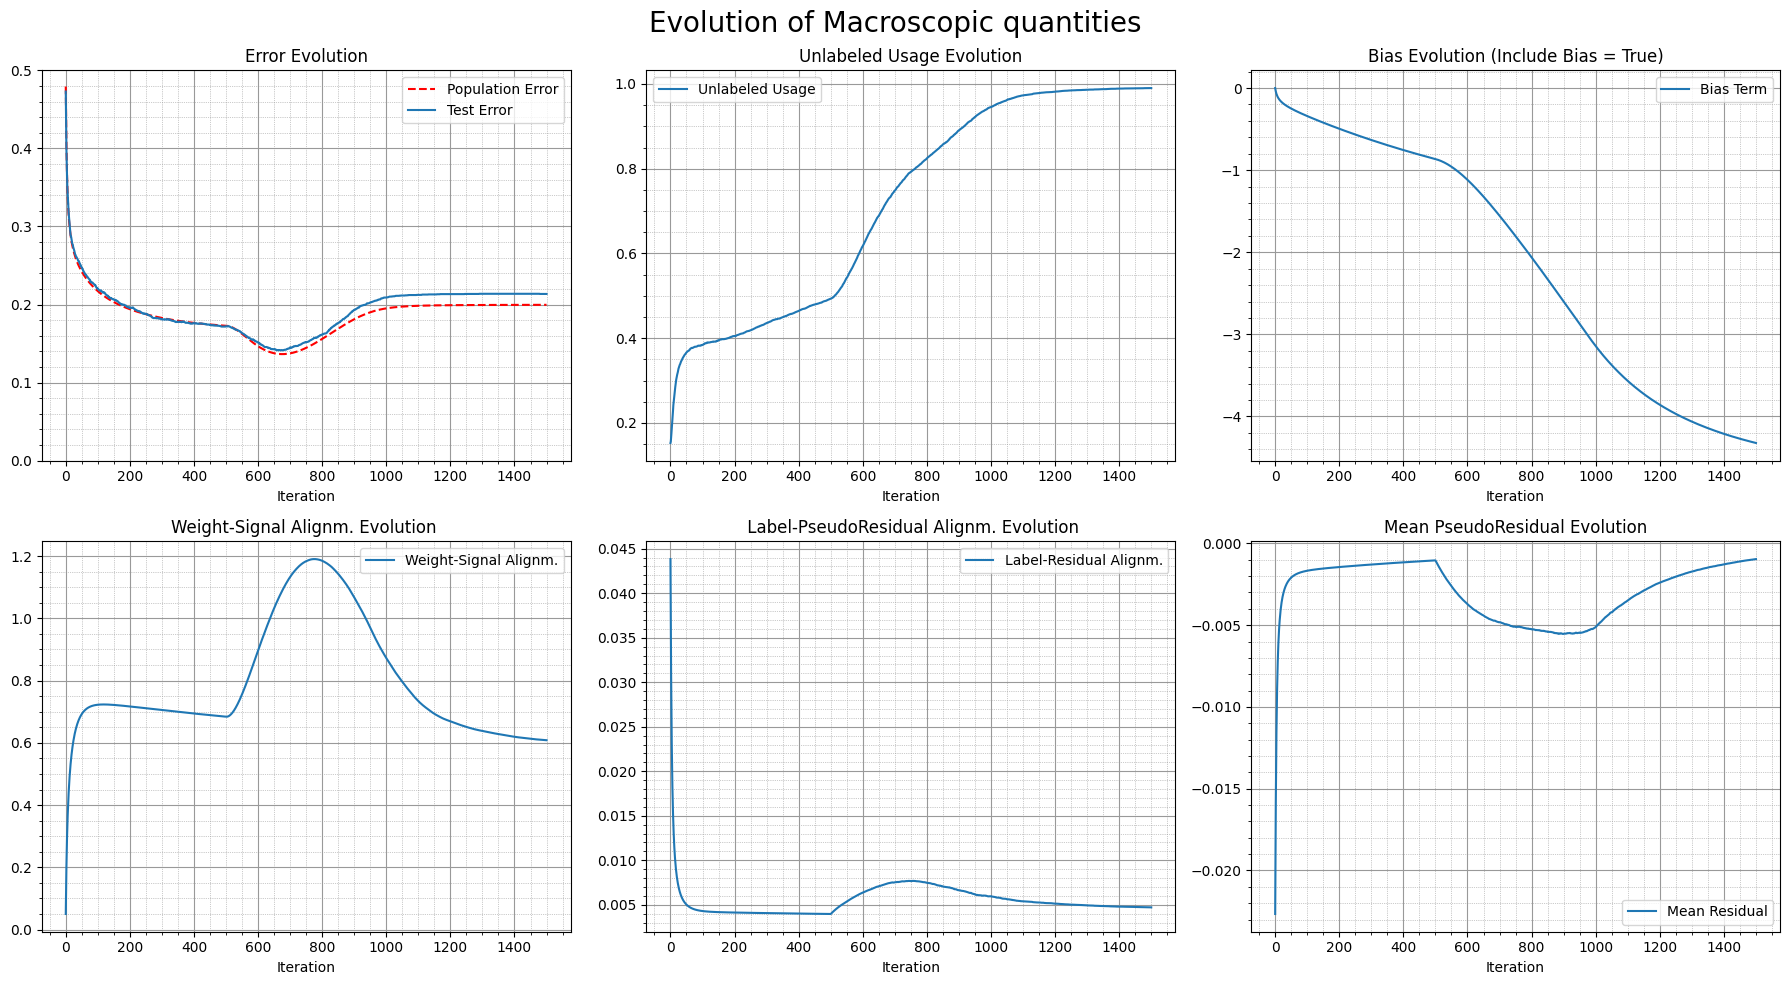

In [43]:
plot_callback(callback)

## Configuration 2a - Symmetric Margins, Without Bias, Small Pseudo-Label Param

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.80),
    negative_margin=-logit(0.80),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

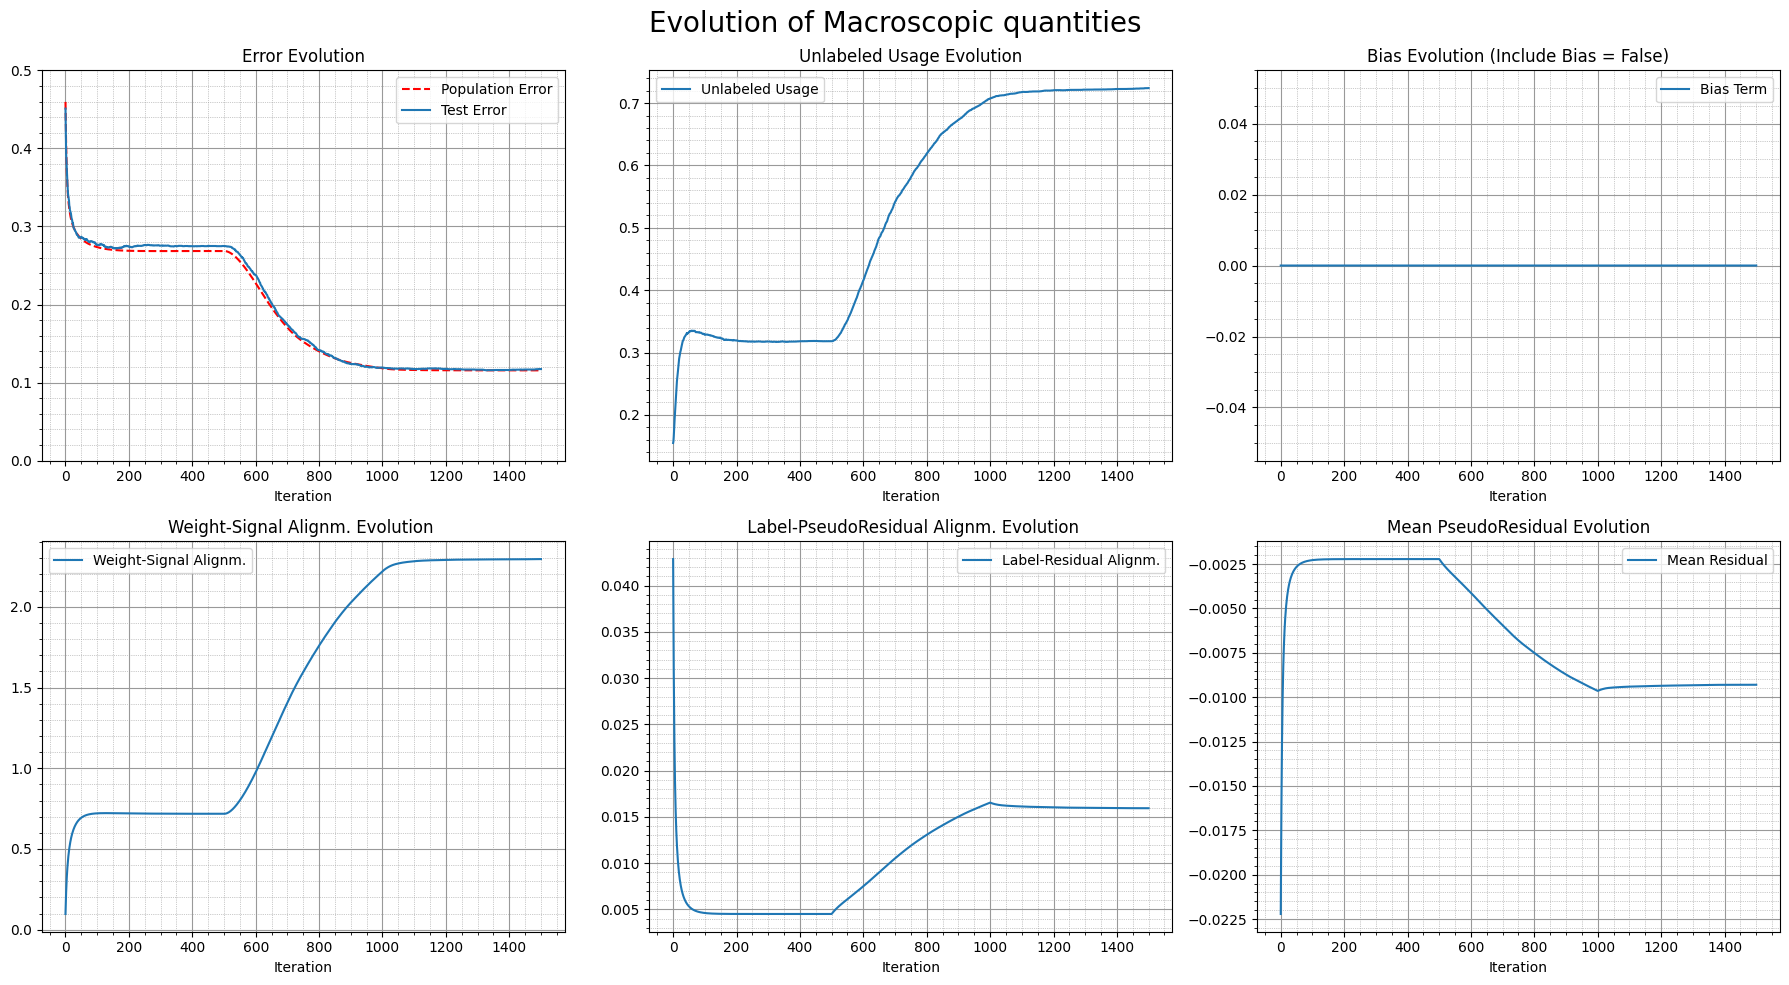

In [324]:
plot_callback(callback)

## Configuration 2b - Symmetric Margins (High Threshold), Without Bias, Small Pseudo-Label Param

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.95),
    negative_margin=-logit(0.95),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

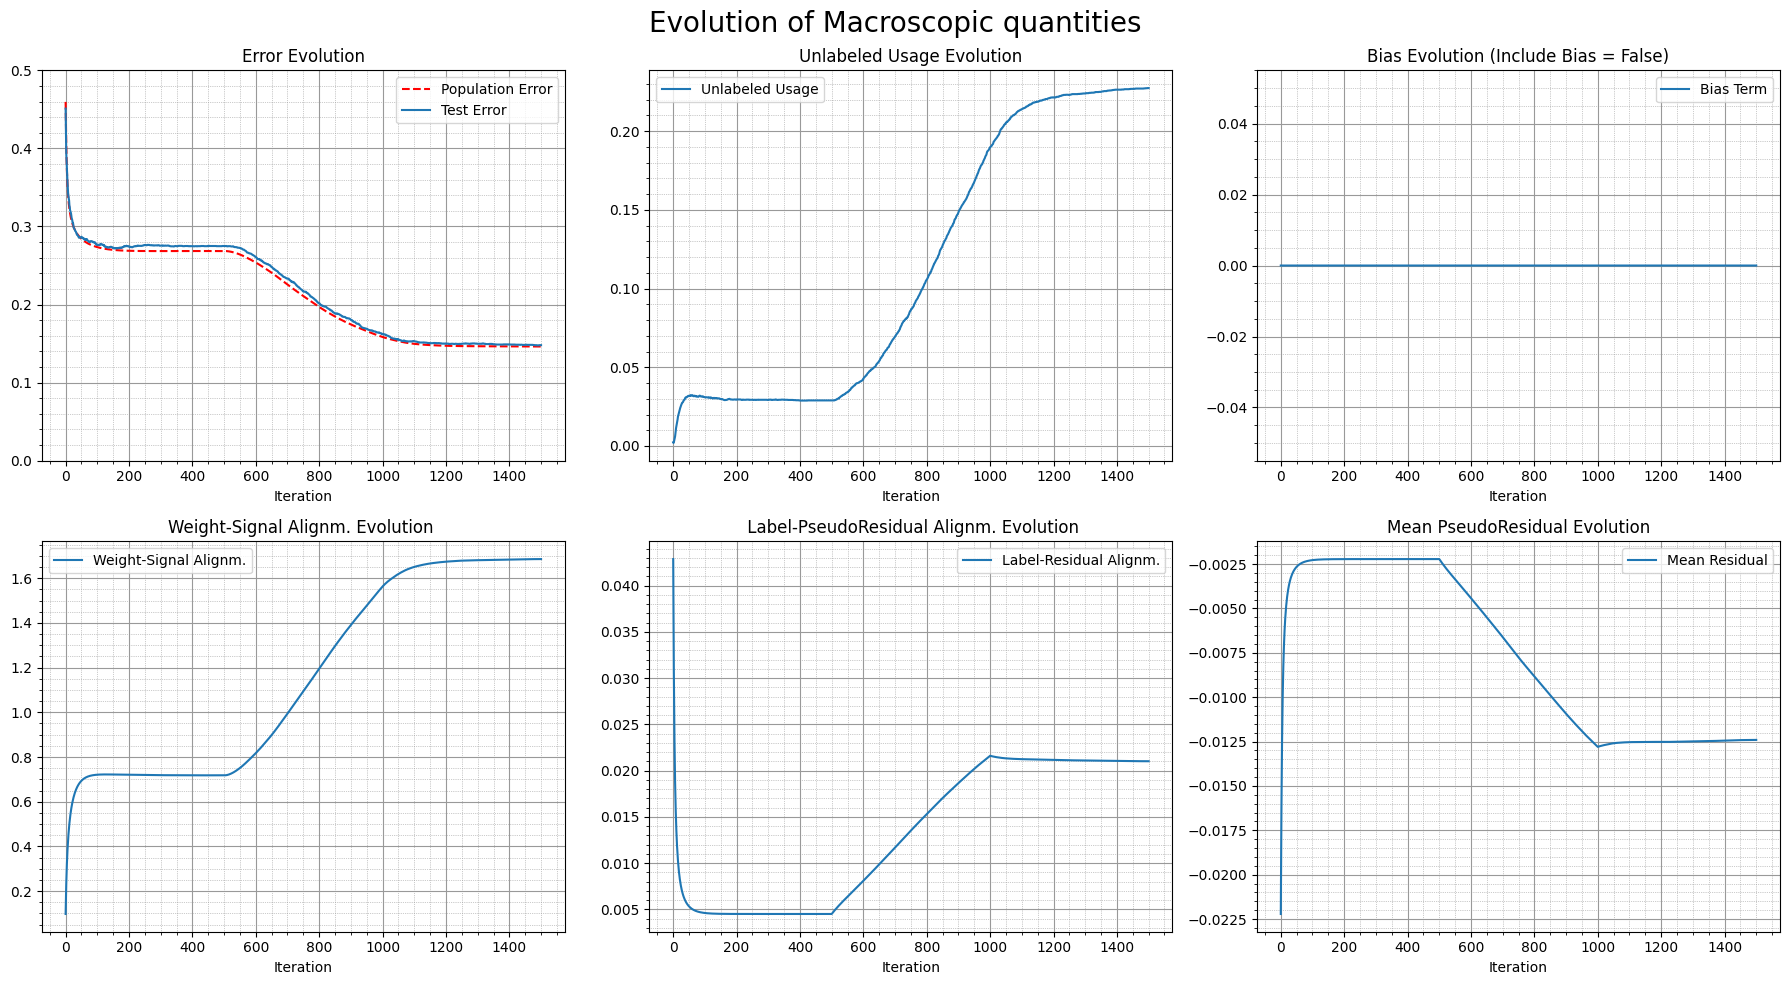

In [326]:
plot_callback(callback)

## Configuration 2c - Symmetric Margins (Low Threshold), Without Bias, Small Pseudo-Label Param

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.60),
    negative_margin=-logit(0.60),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

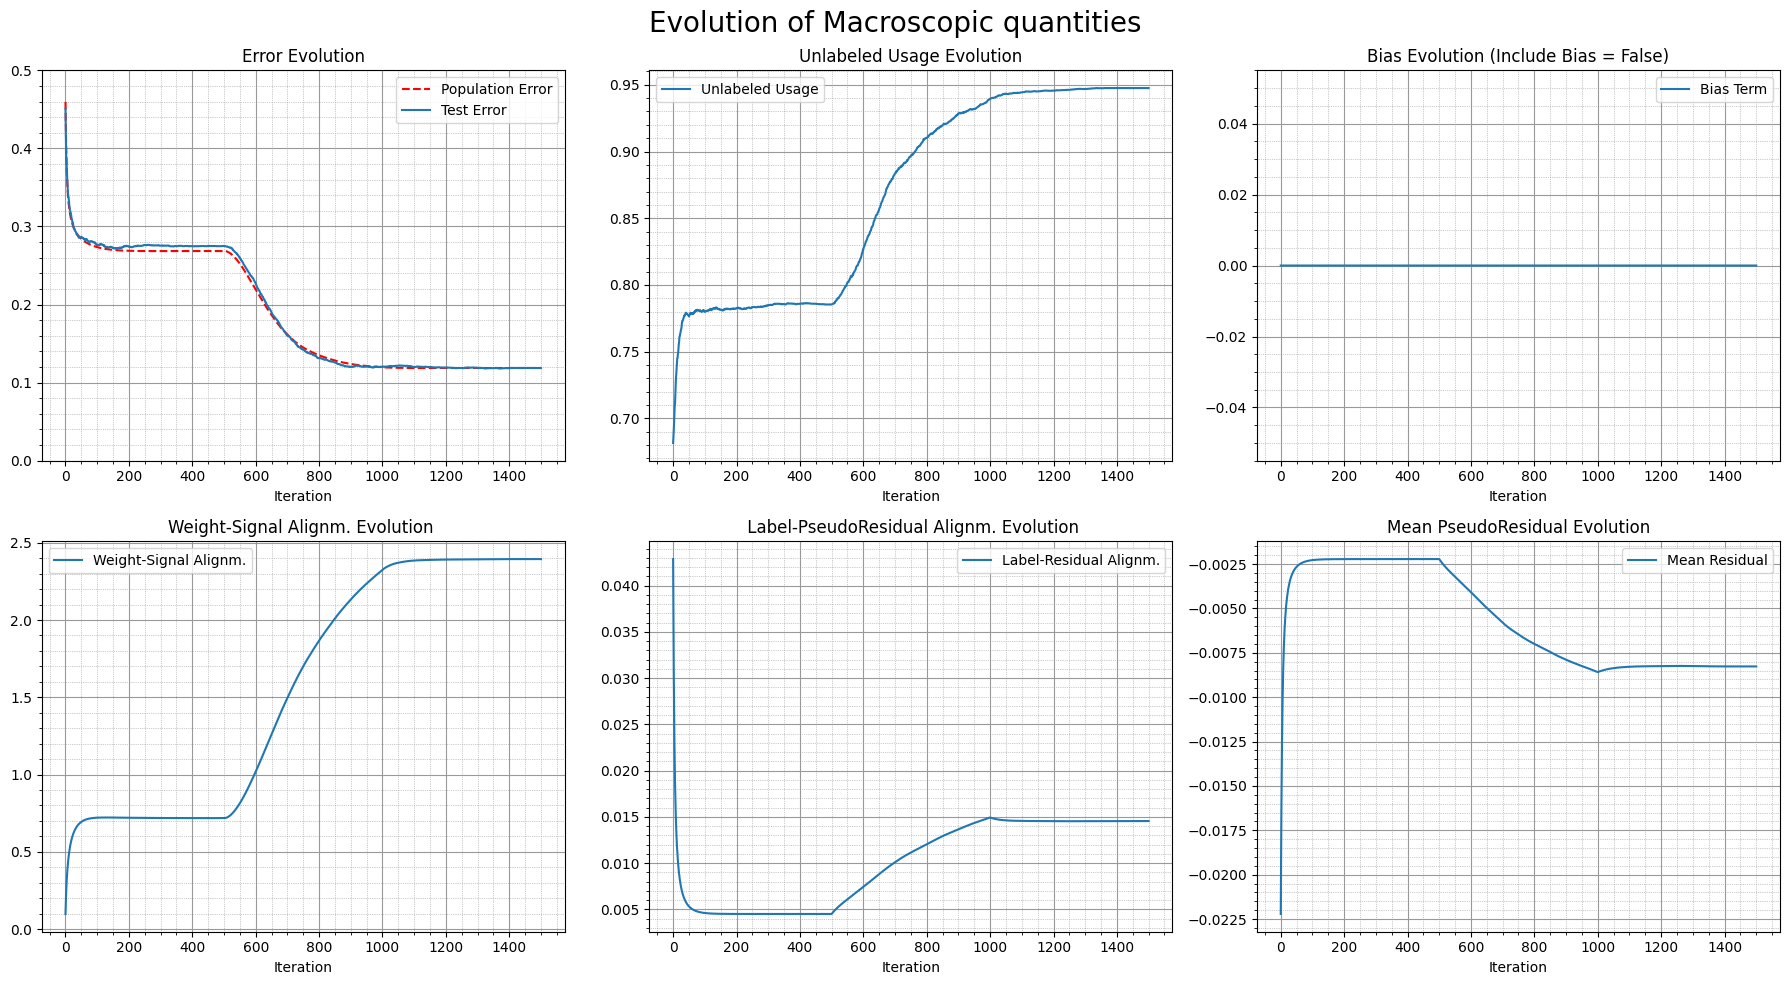

In [328]:
plot_callback(callback)

## Configuration 3a - Asymmetric Margins, Without Bias, Small Pseudo-Label Param

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.95),
    negative_margin=-logit(0.60),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

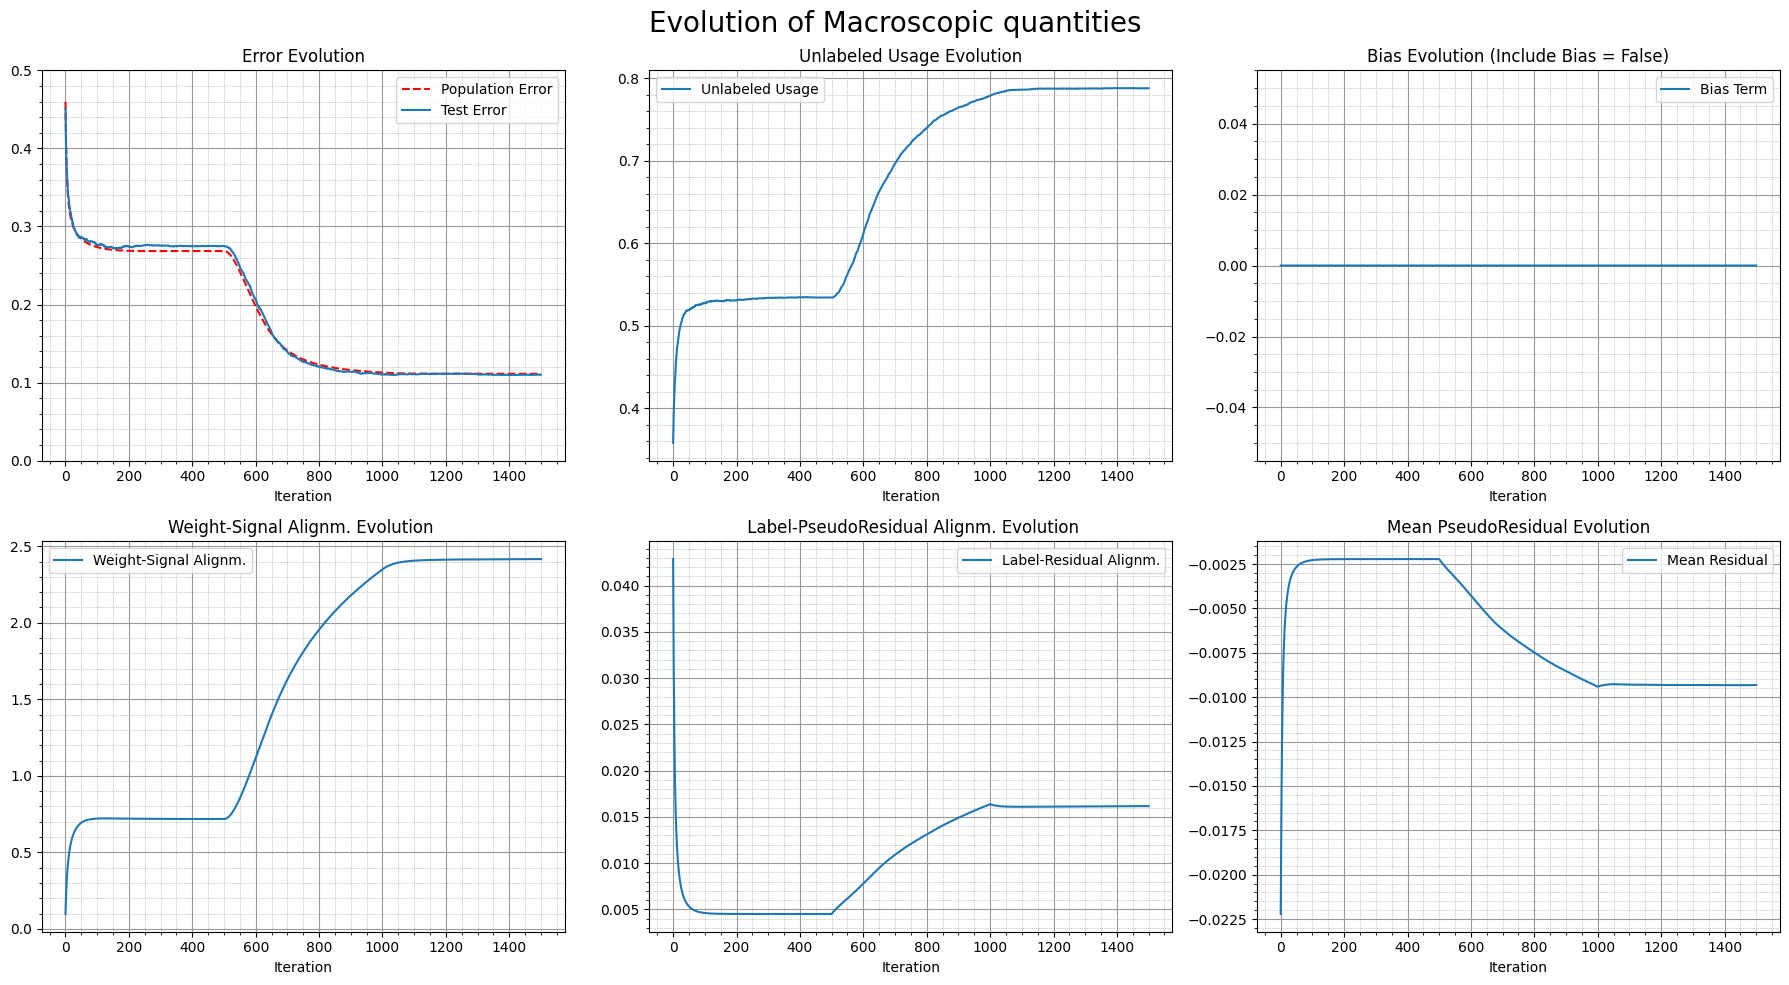

In [330]:
plot_callback(callback)

## Configuration 3b - Asymmetric Margins (Wrong Side), Without Bias, Small Pseudo-Label Param

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.60),
    negative_margin=-logit(0.95),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

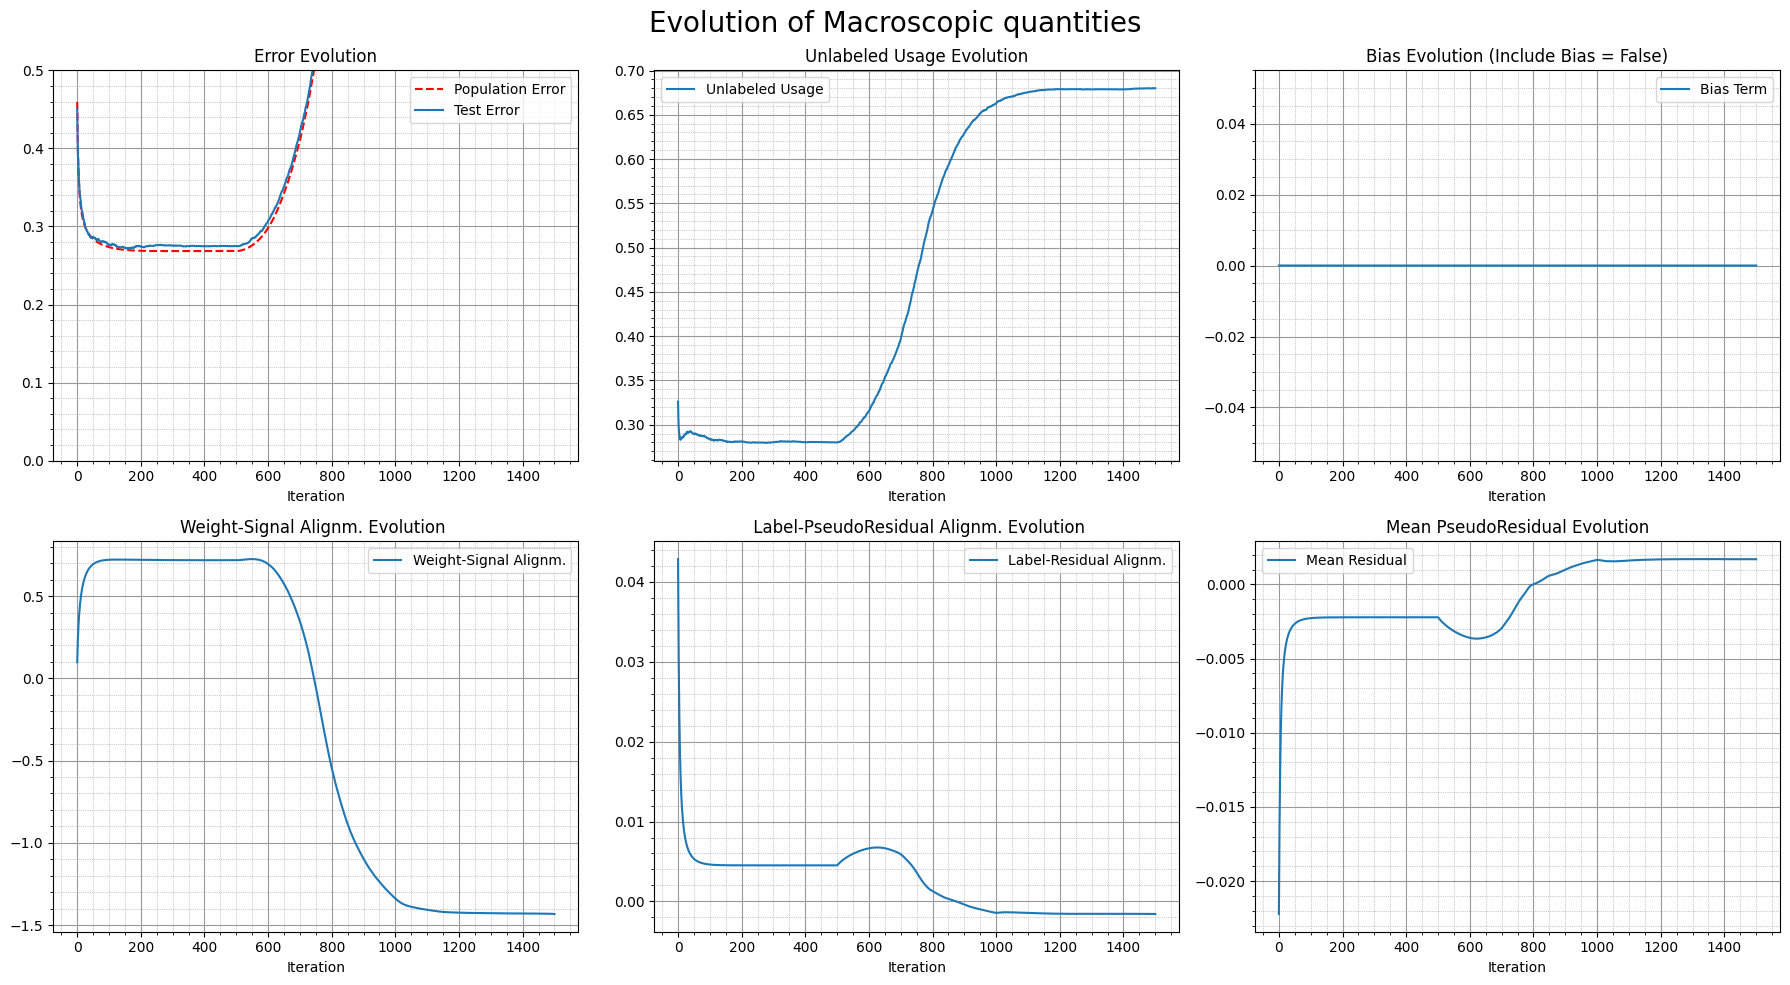

In [332]:
plot_callback(callback)

## Configuration 4a - Asymmetric Margins, Without Bias, Big Pseudo-Label Param

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.95),
    negative_margin=-logit(0.60),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=20.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

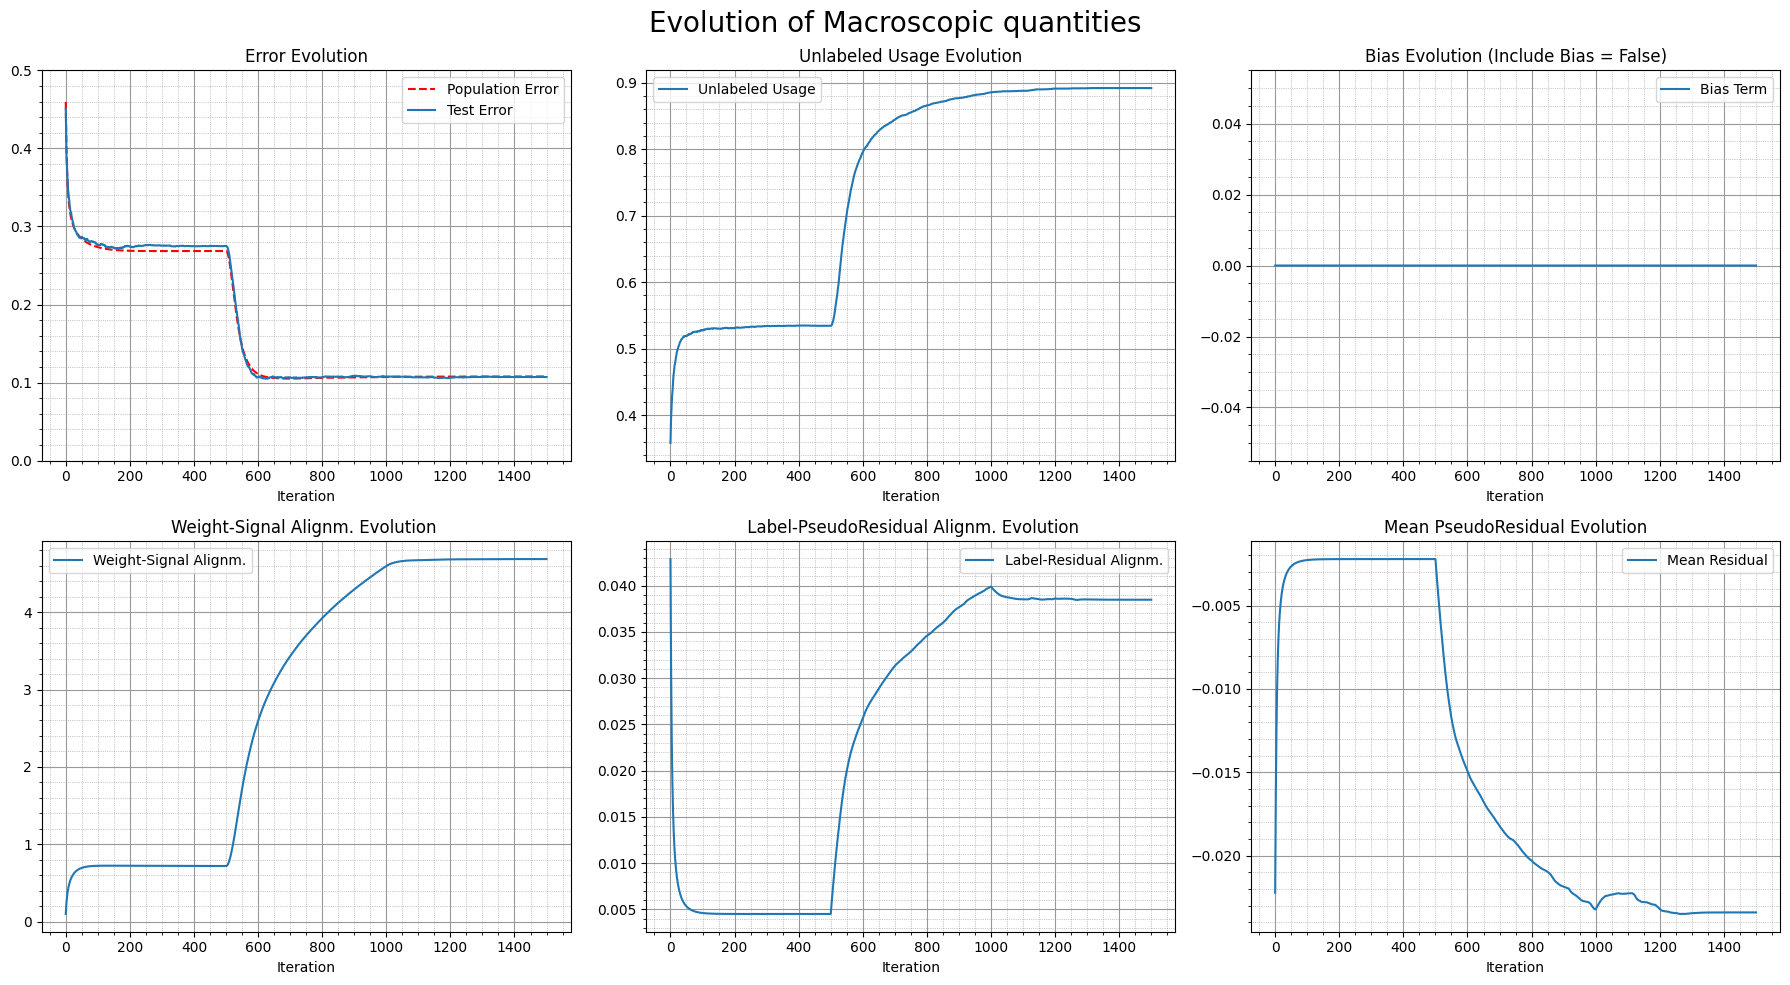

In [334]:
plot_callback(callback)

## Configuration 5 - Asymmetric Margins, With Bias, Small Pseudo-Label Param, Small Step Size

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics=metrics
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1500,
    ramp_start=500,
    ramp_end=1000,
    positive_margin=logit(0.99),
    negative_margin=-logit(0.60),
    penalty_param=0.1,
    step_size=0.01,
    pseudo_label_param=20.0,
    include_bias=True
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

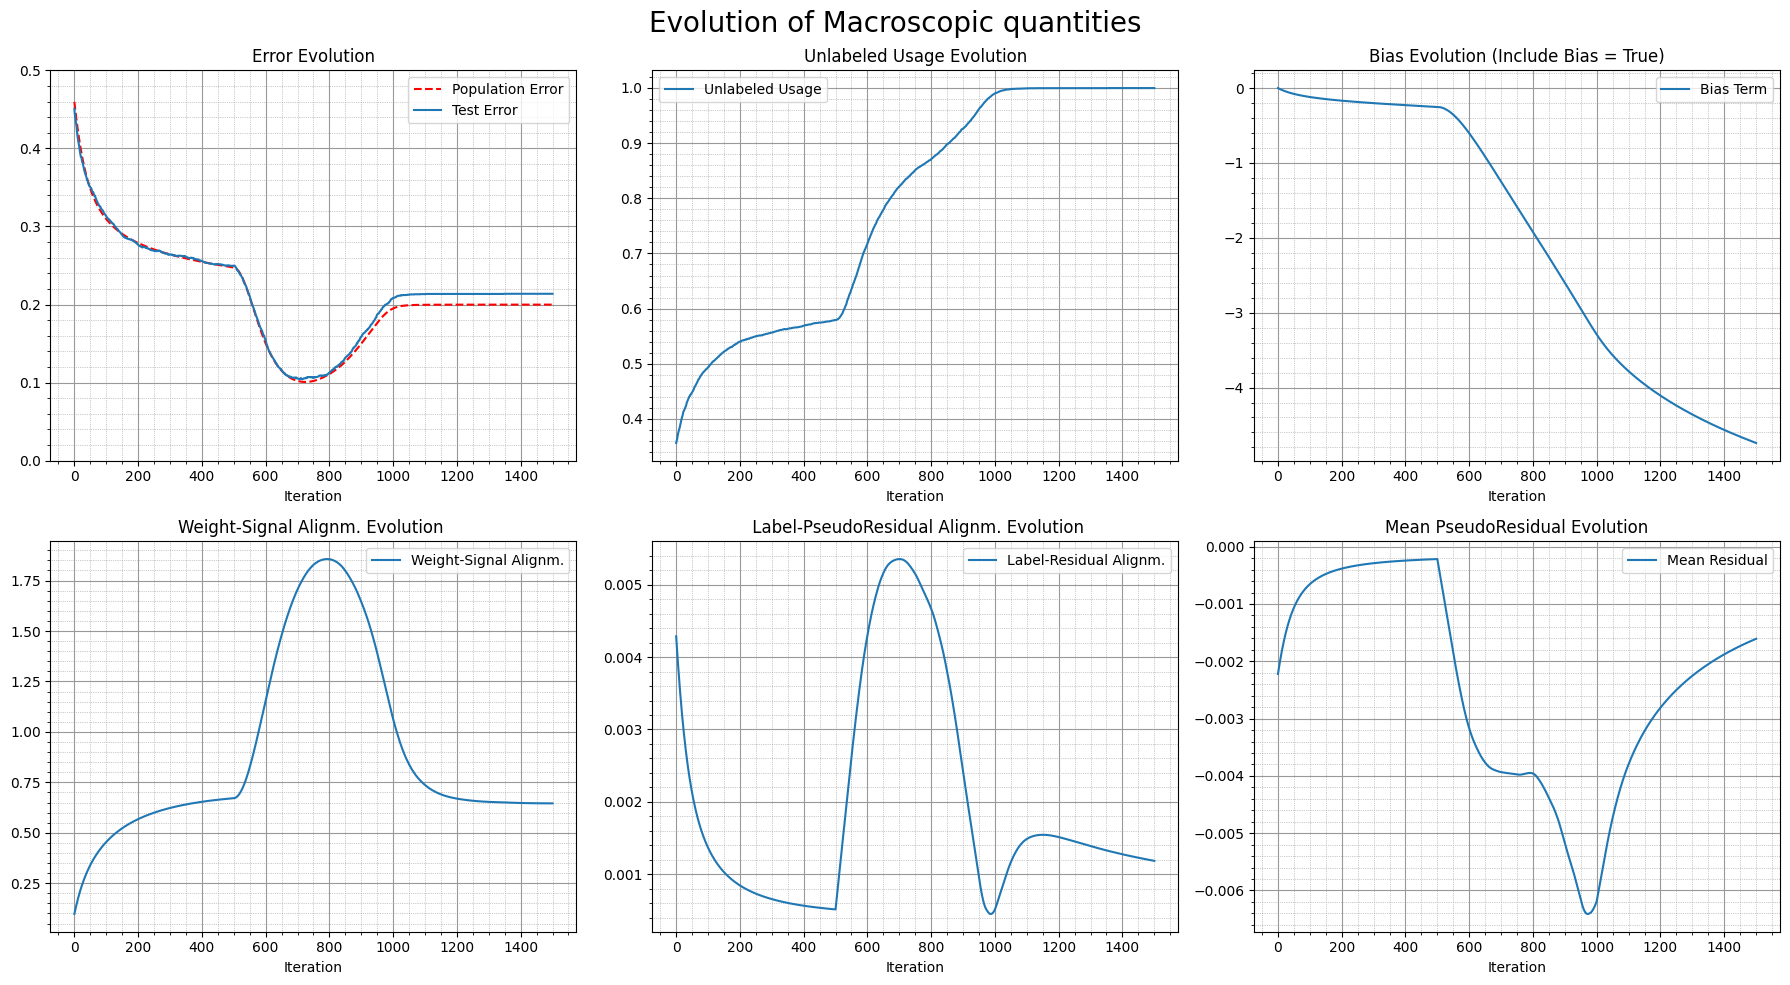

In [336]:
plot_callback(callback)